In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import optimize, signal, special
from sklearn import metrics
from sklearn.linear_model import LinearRegression

In [2]:
results = []

### Load data

In [3]:
df = pd.read_csv("cathet.csv")
df

,t,V
0,0,0.000000
1,39,0.000008
2,131,0.000027
3,184,0.000038
4,214,0.000044
...,...,...
111,6938,0.000927
112,7088,0.000943
113,7272,0.000960
114,7300,0.000963


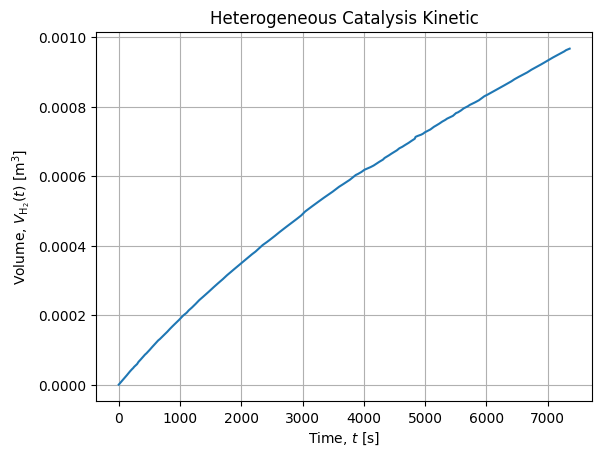

In [4]:
fig, axe = plt.subplots()
axe.plot(df["t"], df["V"])
axe.set_title("Heterogeneous Catalysis Kinetic")
axe.set_xlabel("Time, $t$ $[\mathrm{s}]$")
axe.set_ylabel("Volume, $V_\mathrm{H_2}(t)$ $[\mathrm{m^3}]$")
axe.grid()

In [5]:
R = 8.31446261815324           # J/mol.K
T0 = 292.05                    # K
p0 = 101600                    # Pa
V = 190e-6                     # m3 of isopropanol
m = 2.7677                     # g of Raney Nickel
rho = 785                      # kg/m³
M = 60.1                       # g/mol
n0 = 1000 * rho * V / M        # mol

In [6]:
n0

2.4816971713810316

In [7]:
df["xi"] = p0 * df["V"] / (R * T0)

In [8]:
df["x1"] = df["xi"] / V
df["x2"] = - (n0 / V) * np.log((n0 - df["xi"]) / n0)

In [9]:
df["B/A"] = df["xi"] / (n0 - df["xi"])
df["dxidt1"] = df["xi"].diff() / df["t"].diff()
df["1/r1"] = V / df["dxidt1"]

In [10]:
df

,t,V,xi,x1,x2,B/A,dxidt1,1/r1
0,0,0.000000,0.000000,0.000000,-0.000000,0.000000,NaN,NaN
1,39,0.000008,0.000339,1.783749,1.783871,0.000137,0.000009,21.864063
2,131,0.000027,0.001126,5.923808,5.925152,0.000454,0.000009,22.221904
3,184,0.000038,0.001603,8.434270,8.436994,0.000646,0.000009,21.111656
4,214,0.000044,0.001845,9.711522,9.715134,0.000744,0.000008,23.487920
...,...,...,...,...,...,...,...,...
111,6938,0.000927,0.038791,204.162179,205.774609,0.015879,0.000004,44.353932
112,7088,0.000943,0.039439,207.575526,209.242616,0.016149,0.000004,43.945140
113,7272,0.000960,0.040172,211.429304,213.159215,0.016453,0.000004,47.745348
114,7300,0.000963,0.040314,212.178039,213.920291,0.016513,0.000005,37.396452


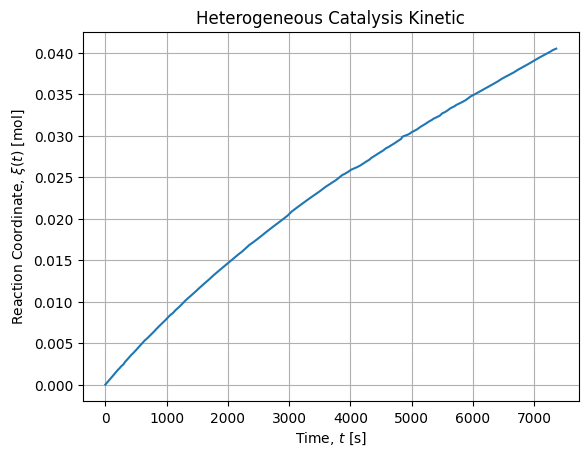

In [11]:
fig, axe = plt.subplots()
axe.plot(df["t"], df["xi"])
axe.set_title("Heterogeneous Catalysis Kinetic")
axe.set_xlabel(r"Time, $t$ $[\mathrm{s}]$")
axe.set_ylabel(r"Reaction Coordinate, $\xi(t)$ $[\mathrm{mol}]$")
axe.grid()

### NLLS w/ Analytical Solution

In [12]:
def model1(t, k1, k2):
    if k2 != 1.:
        return np.real(n0 * (1 - k2 / (1 - k2) * special.lambertw((1 - k2) / k2 * np.exp(- k1 * V * t / (n0 * k2) + (1 - k2) / k2))))
    else:
        return n0 * (1. - np.exp(- (k1 * t * V) / n0))

In [13]:
popt1, pcov1 = optimize.curve_fit(model1, df["t"], df["xi"], p0=[1e-2, 100])
popt1, pcov1

(array([4.74055853e-02, 7.73469604e+01]),
 array([[1.03016125e-08, 5.13022024e-05],
        [5.13022024e-05, 2.64738605e-01]]))

In [14]:
sp1 = np.sqrt(np.diag(pcov1))
sp1

array([1.01496860e-04, 5.14527555e-01])

### Error Surface

In [45]:
k1lin = np.logspace(-3, 1, 200)
k2lin = np.logspace(-1, 3, 200)

In [46]:
K1, K2 = np.meshgrid(k1lin, k2lin)

In [47]:
def factory(t, xi):
    @np.vectorize
    def wrapped(k1, k2):
        return metrics.mean_squared_error(xi, model1(t, k1, k2))
    return wrapped

In [48]:
loss = factory(df["t"], df["xi"])

In [49]:
L = loss(K1, K2)

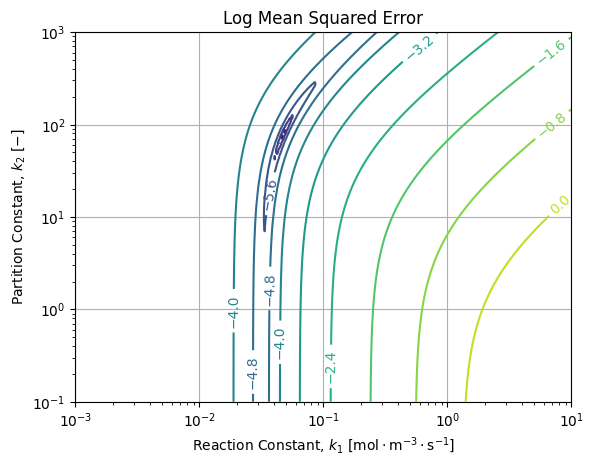

In [56]:
fig, axe = plt.subplots()
C = axe.contour(K1, K2, np.log10(L), 10)
axe.set_xscale("log")
axe.set_yscale("log")
axe.clabel(C, C.levels)
axe.set_title("Log Mean Squared Error")
axe.set_xlabel(r"Reaction Constant, $k_1$ $[\mathrm{mol \cdot m^{-3} \cdot s^{-1}}]$")
axe.set_ylabel(r"Partition Constant, $k_2$ $[-]$")
axe.grid()#which="both")